In [8]:
import pandas as pd

df = pd.read_csv("logs\sokoban_PPO_CUDA_20260220_140931.csv")
print(df.columns)


Index(['episode', 'step', 'reward', 'timestamp', 'cpu_percent', 'ram_percent',
       'ram_used_gb', 'ram_available_gb', 'gpu_util_percent',
       'gpu_mem_used_mb', 'gpu_mem_total_mb', 'gpu_mem_percent', 'action',
       'penalty_ram_penalty', 'penalty_gpu_penalty', 'penalty_cpu_penalty',
       'penalty_total_penalty'],
      dtype='object')


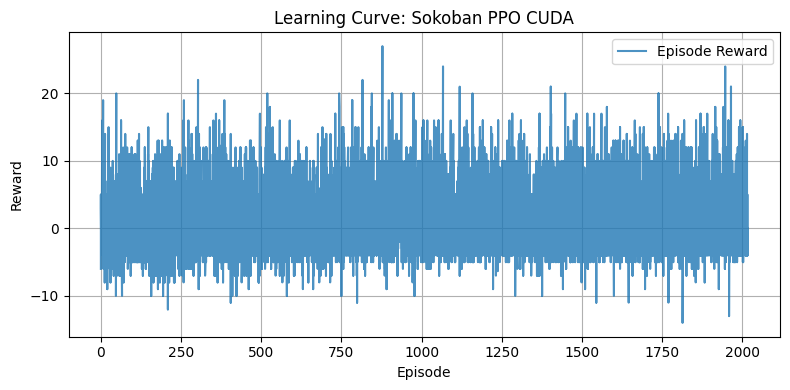

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logs\sokoban_PPO_CUDA_20260220_140931.csv")

plt.figure(figsize=(8,4))
plt.plot(df["episode"], df["reward"], label="Episode Reward", alpha=0.8)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Learning Curve: Sokoban PPO CUDA")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


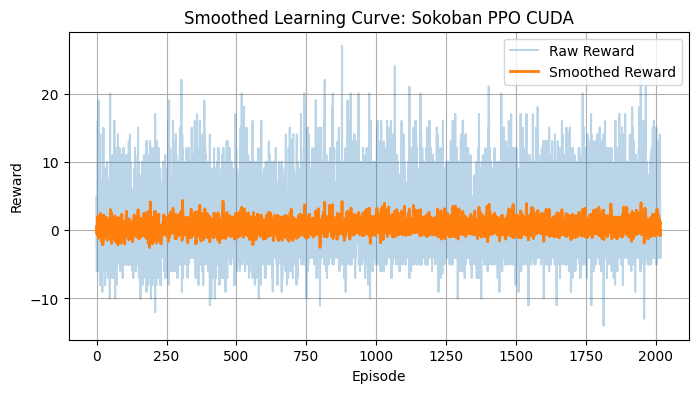

In [10]:
df["reward_smooth"] = df["reward"].rolling(window=10).mean()

plt.figure(figsize=(8,4))
plt.plot(df["episode"], df["reward"], alpha=0.3, label="Raw Reward")
plt.plot(df["episode"], df["reward_smooth"], linewidth=2, label="Smoothed Reward")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Smoothed Learning Curve: Sokoban PPO CUDA")
plt.legend()
plt.grid(True)
plt.show()


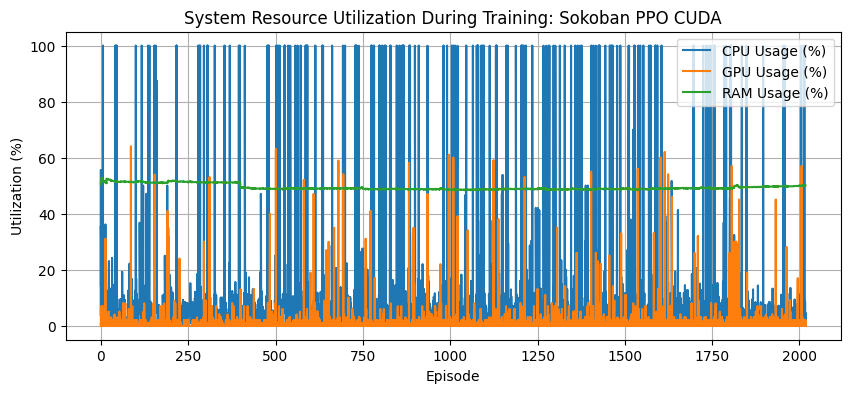

In [11]:
plt.figure(figsize=(10,4))
plt.plot(df["episode"], df["cpu_percent"], label="CPU Usage (%)")
plt.plot(df["episode"], df["gpu_util_percent"], label="GPU Usage (%)")
plt.plot(df["episode"], df["ram_percent"], label="RAM Usage (%)")

plt.xlabel("Episode")
plt.ylabel("Utilization (%)")
plt.title("System Resource Utilization During Training: Sokoban PPO CUDA")
plt.legend()
plt.grid(True)
plt.show()


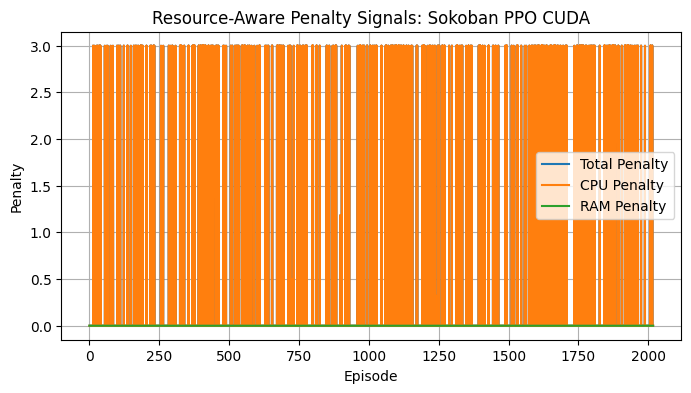

In [12]:
plt.figure(figsize=(8,4))
plt.plot(df["episode"], df["penalty_total_penalty"], label="Total Penalty")
plt.plot(df["episode"], df["penalty_cpu_penalty"], label="CPU Penalty")
plt.plot(df["episode"], df["penalty_ram_penalty"], label="RAM Penalty")

plt.xlabel("Episode")
plt.ylabel("Penalty")
plt.title("Resource-Aware Penalty Signals: Sokoban PPO CUDA")
plt.legend()
plt.grid(True)
plt.show()


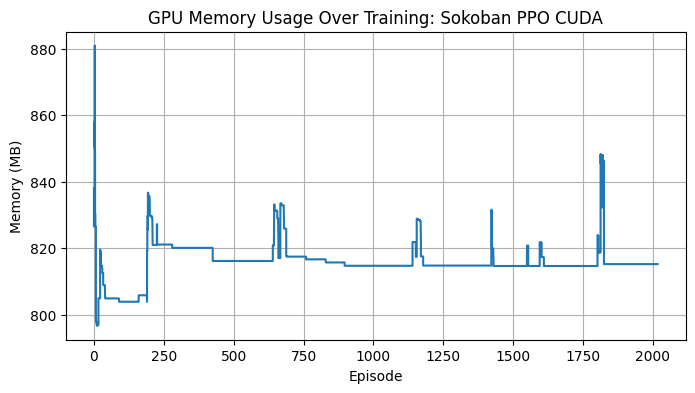

In [13]:
plt.figure(figsize=(8,4))
plt.plot(df["episode"], df["gpu_mem_used_mb"], label="GPU Memory Used (MB)")
plt.xlabel("Episode")
plt.ylabel("Memory (MB)")
plt.title("GPU Memory Usage Over Training: Sokoban PPO CUDA")
plt.grid(True)
plt.show()


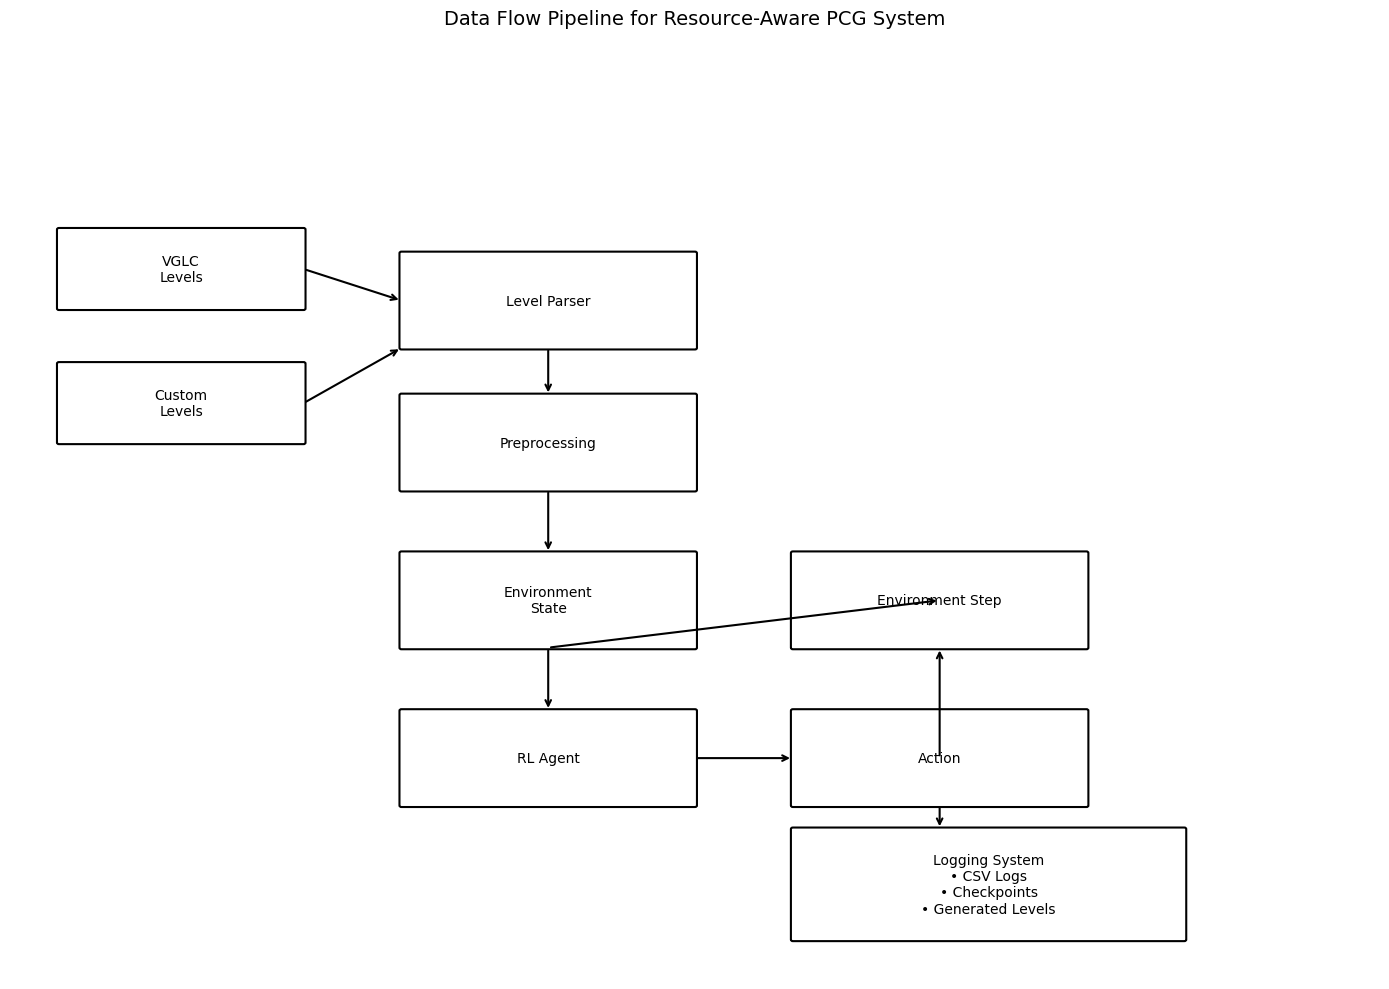

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Arrow

# Helper function to draw boxes
def draw_box(ax, x, y, w, h, text):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=10)

# Create figure
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14)
ax.set_ylim(0, 12)
ax.axis('off')

# === Input Sources ===
draw_box(ax, 0.5, 8.5, 2.5, 1, "VGLC\nLevels")
draw_box(ax, 0.5, 6.8, 2.5, 1, "Custom\nLevels")

# Processing blocks
draw_box(ax, 4, 8.0, 3, 1.2, "Level Parser")
draw_box(ax, 4, 6.2, 3, 1.2, "Preprocessing")

# Environment
draw_box(ax, 4, 4.2, 3, 1.2, "Environment\nState")

# RL agent
draw_box(ax, 4, 2.2, 3, 1.2, "RL Agent")

# Action & Env Step
draw_box(ax, 8, 2.2, 3, 1.2, "Action")
draw_box(ax, 8, 4.2, 3, 1.2, "Environment Step")

# Output / Logging
draw_box(ax, 8, 0.5, 4, 1.4, "Logging System\n• CSV Logs\n• Checkpoints\n• Generated Levels")

# Arrows
def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))

# Flow arrows
arrow(3.0, 9.0, 4.0, 8.6)      # VGLC → Parser
arrow(3.0, 7.3, 4.0, 8.0)      # Custom → Parser
arrow(5.5, 8.0, 5.5, 7.4)      # Parser → Preprocess
arrow(5.5, 6.2, 5.5, 5.4)      # Preprocess → Env
arrow(5.5, 4.2, 5.5, 3.4)      # Env → Agent
arrow(7.0, 2.8, 8.0, 2.8)      # Agent → Action
arrow(9.5, 2.8, 9.5, 4.2)      # Action → Env Step
arrow(5.5, 4.2, 9.5, 4.8)      # Env → Env Step
arrow(9.5, 2.2, 9.5, 1.9)      # Down to logs

plt.title("Data Flow Pipeline for Resource-Aware PCG System", fontsize=14)
plt.tight_layout()
plt.show()
